In [14]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [15]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

In [16]:
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

In [21]:
# make the values in job_skills hashable so we can group on them
df_DA_US['job_skills'] = df_DA_US['job_skills'].apply(
	lambda x: tuple(x) if isinstance(x, list) else x
)

df_DA_US_group = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_DA_US_pay = df_DA_US_group.sort_values(by='median', ascending =False).head(10)
df_DA_skills = df_DA_US_group.sort_values(by='count', ascending =False).head(10).sort_values(by='median', ascending =False).head(10)

In [20]:
df_DA_skills

,count,median
job_skills,,
"(excel,)",161,70000.0
"(sql,)",120,80000.0
"(sql, excel)",88,85887.5
"(sql, python)",38,87500.0
"(sql, tableau)",37,97500.0
"(flow,)",27,89833.5
"(excel, powerpoint)",26,84500.0
"(go,)",21,75000.0
"(tableau,)",20,92500.0


C:\Users\hp\AppData\Local\Temp\ipykernel_12732\2991348170.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


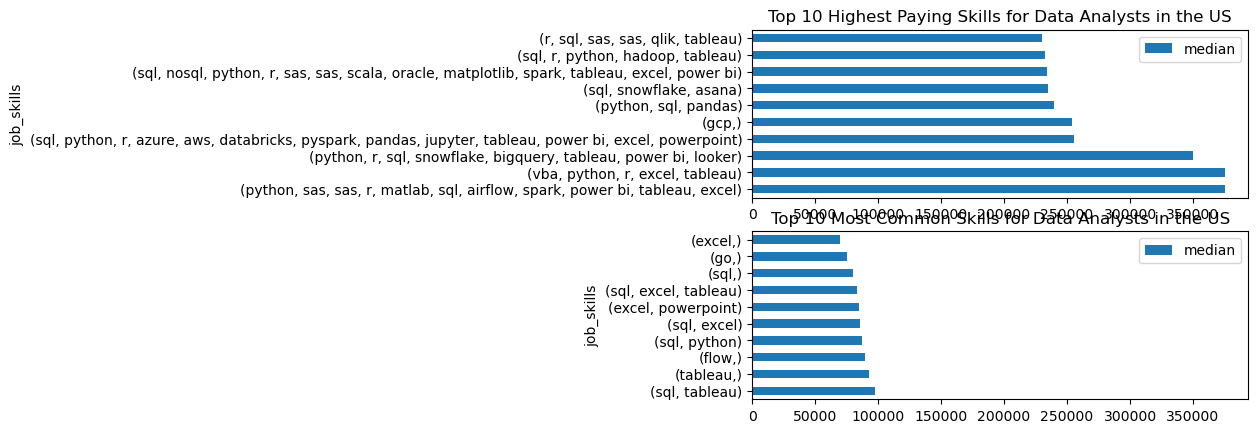

In [23]:
fig,ax = plt.subplots(2,1)
df_DA_US_pay.plot(kind='barh', y='median', ax=ax[0], title='Top 10 Highest Paying Skills for Data Analysts in the US')
df_DA_skills.plot(kind='barh', y='median', ax=ax[1], title='Top 10 Most Common Skills for Data Analysts in the US')
ax[1].set_xlim(ax[0].get_xlim())  # Set the x-axis limits of the second plot to match the first plot    
plt.tight_layout()
plt.show()